In [1]:
import earthaccess
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

In [2]:
path = "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L2_CLOUD_GPC_v3_0/PACE_HARP2.20250706T192050.L2.CLOUD_GPC.V3_0.nc"
cloud_ds = xr.open_dataset(path, group='geophysical_data')
nav_ds = xr.open_dataset(path, group='geolocation_data')

In [3]:
data = cloud_ds['cloud_top_altitude']
cer = cloud_ds['cloud_bow_droplet_effective_radius']

lon = nav_ds['longitude']
lat = nav_ds['latitude']

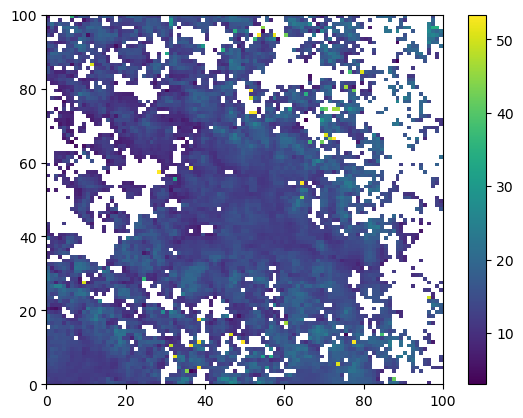

In [4]:
plt.pcolormesh(cer[80:180, 250:350])
plt.colorbar()
plt.show()

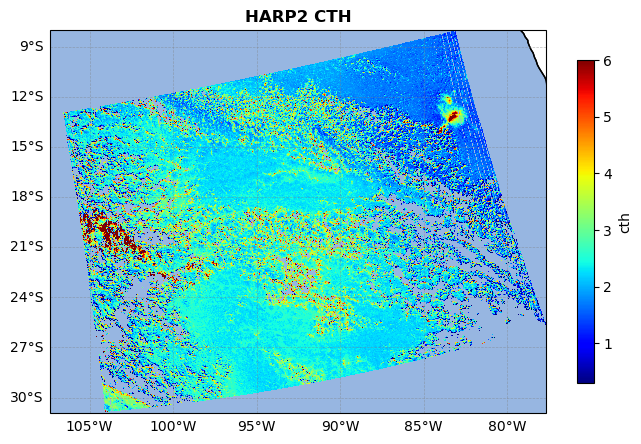

In [5]:
plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

data_km= data/1000
img = ax.pcolormesh(lon, lat, data_km, vmax=6, cmap='jet', shading='auto')
# img = ax.pcolormesh(lon, lat, data, vmax=30, cmap='jet', shading='auto')
ax.coastlines()
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
ax.add_feature(cfeature.OCEAN)
ax.set_title('HARP2 CTH', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
# gl.xlines = False
# gl.ylines = False

cbar = plt.colorbar(img, ax=ax, orientation='vertical', shrink=0.7, pad=0.05)
cbar.set_label('cth')

plt.show()

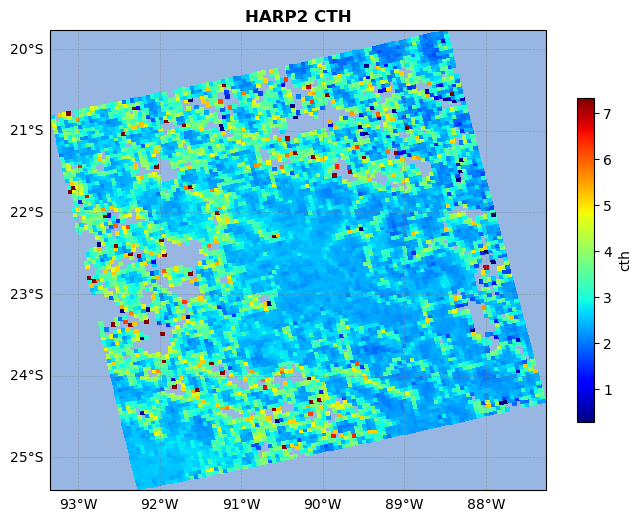

7.3174953


In [6]:
plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

img = ax.pcolormesh(lon[80:180, 250:350], lat[80:180, 250:350], data_km[80:180, 250:350], cmap='jet', shading='auto')

ax.coastlines()
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
ax.add_feature(cfeature.OCEAN)
ax.set_title('HARP2 CTH', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
# gl.xlines = False
# gl.ylines = False

cbar = plt.colorbar(img, ax=ax, orientation='vertical', shrink=0.7, pad=0.05)
cbar.set_label('cth')

plt.show()

print(np.nanmax(data_km[80:180, 250:350]))

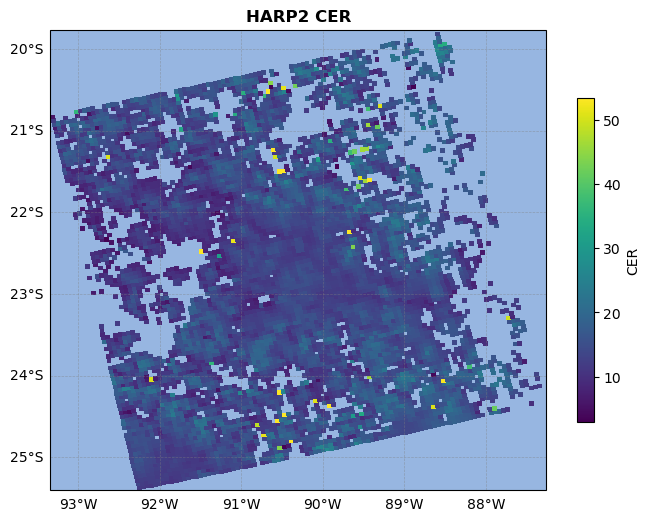

53.36896


In [7]:
plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

img = ax.pcolormesh(lon[80:180, 250:350], lat[80:180, 250:350], cer[80:180, 250:350], cmap='viridis', shading='auto')

ax.coastlines()
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
ax.add_feature(cfeature.OCEAN)
ax.set_title('HARP2 CER', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
# gl.xlines = False
# gl.ylines = False

cbar = plt.colorbar(img, ax=ax, orientation='vertical', shrink=0.7, pad=0.05)
cbar.set_label('CER')

plt.show()

print(np.nanmax(cer[80:180, 250:350]))

In [8]:
def find_nearest_indices(z, CTH):
    indices = [np.abs(z - CTH).argmin()]
    return indices


def write_shdom_RCbC_input(nx,ny,z,T,dx,dy,re,CTH):
    
    dz_C=z[1:]-z[0:-1]
    dz=dz_C[0]

    ##############################################    
    ########################################################################################
    save_directory="/umbc/rs/pi_zzbatmos/common/Exchange/For_Adeleke/"
    file_name_lwc=save_directory+"Recon_PACECLD.lwc"
    #######################################################################
    
    file_name=file_name_lwc

    fout=open(file_name ,'w')   ## col_i commented out
             
    fout.write("2  parameter LWC file \n")
    fout.write("{0:4d} {1:4d} {2:4d} \n".format(nx,ny,len(z)))
    fout.write("{0:7.3f} {1:7.3f} \n".format(dx,dy))

    for i in range(len(z)):
        fout.write('{0:8.4f}'.format(z[i]))
    fout.write('\n')

 
    for i in range(len(z)):
        fout.write('{0:7.2f}  '.format(T[i]))
    fout.write('\n')
    ####################################################################################
    #lwc= (cer*cot)/(1.5*1000*0.03)

    #############################################################################
    
    lwc_Wcolumn=np.empty([nx,ny])
    
    lwp=np.zeros([100,100])
    cot=np.zeros([100,100])
    for ix in range(nx):
        for iy in range(ny):
            #lwc_Wcolumn[ix,iy]= ((cer[ix,iy]*cot[ix,iy])/(1.5*1e3*dz))
            
            lwclayer=np.zeros([nx,ny,len(z)])
            cerlayer=np.ones([nx,ny,len(z)])

            for iz in range(len(z)):
                CT_Idx = np.int64(find_nearest_indices(z, CTH[ix,iy]))[0]
                CBH= 0.36 ##0.45  
                CBH_index=np.int64(find_nearest_indices(z, CBH))[0]
                #if CTH[ix,iy] > 0.44  and Cld_Mask[ix,iy]==1:
    
                
                if CTH[ix,iy] > 0.404999:
                #if CTH[ix,iy] > 0.44:
 
                    ############
                    length=np.int64(CT_Idx-CBH_index)
                    for ilen in range(CBH_index,CT_Idx):
                        #####################
                       lwclayer[ix,iy,ilen]=0.05 ##0.15  #/length ##np.nan_to_num(float(lwc_Wcolumn[ix,iy]/length))
                       cerlayer[ix,iy,ilen] = np.nan_to_num(re[ix,iy].values)
 
                        #####################
                        #if np.nan_to_num(float(cer[ix, iy]), nan=1.0) > 1.0:
                         #  lwclayer[CT_Idx-ilen]= 3/length ##np.nan_to_num(float(lwc_Wcolumn[ix,iy]/length))
                          # cerlayer[CT_Idx-ilen] = np.nan_to_num(float(cer[ix, iy]), nan=1.0)
                    ###########################################################
                else:
                    
                    lwclayer[ix,iy,CT_Idx]=0 #np.nan_to_num(float(lwc_Wcolumn[ix,iy]/4))
                    lwclayer[ix,iy,CT_Idx-1]=0#np.nan_to_num(float(lwc_Wcolumn[ix,iy]/4))
                    lwclayer[ix,iy,CT_Idx-2]=0#np.nan_to_num(float(lwc_Wcolumn[ix,iy]/4))
                    lwclayer[ix,iy,CT_Idx-3]=0#np.nan_to_num(float(lwc_Wcolumn[ix,iy]/4))
                    #lwclayer[ix,iy,CT_Idx-4]=0#np.nan_to_num(float(lwc_Wcolumn[ix,iy]/4))
                    #lwclayer[ix,iy,CT_Idx-5]=0#np.nan_to_num(float(lwc_Wcolumn[ix,iy]/4))
                    #lwclayer[ix,iy,CT_Idx-6]=0#np.nan_to_num(float(lwc_Wcolumn[ix,iy]/4))
                    #lwclayer[ix,iy,CT_Idx-7]=0#np.nan_to_num(float(lwc_Wcolumn[ix,iy]/4))
                    #lwclayer[ix,iy,CT_Idx-8]=0#np.nan_to_num(float(lwc_Wcolumn[ix,iy]/4))
                    #lwclayer[ix,iy,CT_Idx-9]=0#np.nan_to_num(float(lwc_Wcolumn[ix,iy]/4))

                    cerlayer[ix,iy,CT_Idx]=1 #np.nan_to_num(float(cer[ix, iy]), nan=1.0)
                    cerlayer[ix,iy,CT_Idx-1] =1 #np.nan_to_num(float(cer[ix, iy]), nan=1.0)
                    cerlayer[ix,iy,CT_Idx-2] =1 #np.nan_to_num(float(cer[ix, iy]), nan=1.0)
                    cerlayer[ix,iy,CT_Idx-3] =1 #np.nan_to_num(float(cer[ix, iy]), nan=1.0)
                    #cerlayer[ix,iy,CT_Idx-4] =1 #np.nan_to_num(float(cer[ix, iy]), nan=1.0)
                    #cerlayer[ix,iy,CT_Idx-5] =1 #np.nan_to_num(float(cer[ix, iy]), nan=1.0)
                    #cerlayer[ix,iy,CT_Idx-6] =1 #np.nan_to_num(float(cer[ix, iy]), nan=1.0)
                    #cerlayer[ix,iy,CT_Idx-7] =1 #np.nan_to_num(float(cer[ix, iy]), nan=1.0)
                    #cerlayer[ix,iy,CT_Idx-8] =1 #np.nan_to_num(float(cer[ix, iy]), nan=1.0)
                    #cerlayer[ix,iy,CT_Idx-9] =1 #np.nan_to_num(float(cer[ix, iy]), nan=1.0)
                
            
              
                fout.write('{0:4d}  {1:4d}  {2:4d}  {3:7.5f}   {4:6.3f} \n'.format(iy+1,ix+1,iz+1,lwclayer[ix,iy,iz],cerlayer[ix,iy,iz]))
                
            lwp[ix,iy]=np.nansum(lwclayer[ix,iy,:])*0.09*1000
            cot[ix,iy]=(3/2)*lwp[ix,iy]/np.nan_to_num(re[ix,iy].values)


    np.save(save_directory+"ReconPACE_LWP.npy", np.copy(lwp))
    np.save(save_directory+"ReconPACE_COT.npy", np.copy(cot))
    fout.close()

In [9]:
z=np.arange(0, 7.4, 0.09)
T=np.linspace(294.35194, 298.15, len(z))[::-1] 
        
nx,ny= 100,100
dx,dy= 2.6,2.6

CTH= np.nan_to_num(data[80:180, 250:350])
re= cer[80:180, 250:350]

In [10]:
write_shdom_RCbC_input(nx, ny, z, T, dx, dy, re, CTH)

/tmp/ipykernel_2226655/922232182.py:100: RuntimeWarning: divide by zero encountered in scalar divide
  cot[ix,iy]=(3/2)*lwp[ix,iy]/np.nan_to_num(re[ix,iy].values)
/tmp/ipykernel_2226655/922232182.py:100: RuntimeWarning: invalid value encountered in scalar divide
  cot[ix,iy]=(3/2)*lwp[ix,iy]/np.nan_to_num(re[ix,iy].values)


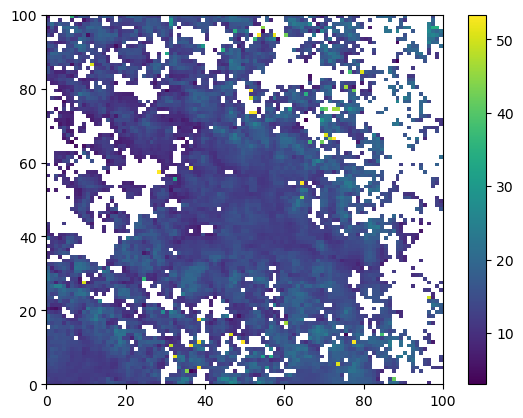

In [63]:
plt.pcolormesh(re.values)
plt.colorbar()
plt.show()

In [61]:
for iix in range(10):
    for iiy in range(10):
        print(np.nan_to_num(re[iix,iiy].values))

11.822865
11.56046
11.102768
11.191112
12.173743
12.213695
11.208632
10.697246
10.65237
11.027109
13.401875
11.944526
11.621395
12.222304
12.2256365
12.590718
12.378997
11.962792
10.771454
11.318416
11.837763
12.408275
12.187585
12.290338
12.273773
11.735407
12.01868
12.403677
11.834951
11.601246
12.424208
13.215487
13.236024
12.56968
12.659286
11.980813
11.769699
11.577846
12.348391
12.030836
13.204199
13.800103
14.35233
13.143289
12.929614
12.367379
12.482275
11.73105
11.800405
12.8485565
13.744296
15.054858
14.279643
13.371422
13.0346155
11.836154
12.24999
12.203134
11.725472
12.505109
14.725265
15.374194
15.009542
13.633128
13.780992
13.102136
11.812374
12.341776
12.211806
11.852976
13.493331
16.235224
16.306355
14.244736
13.694145
13.566164
11.324979
12.186575
12.407903
11.270088
13.211922
15.499889
14.18258
14.541675
13.574586
12.839774
11.834126
12.236035
12.338263
10.169839
13.138798
16.567455
15.720183
14.343938
15.564313
13.709883
12.443968
13.010179
13.247355
10.65979
